In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

edges = pd.read_csv("string_interactions.tsv", sep="\t")

In [82]:
display(edges)

,#node1,node2,node1_string_id,node2_string_id,neighborhood_on_chromosome,gene_fusion,phylogenetic_cooccurrence,homology,coexpression,experimentally_determined_interaction,database_annotated,automated_textmining,combined_score
0,ACHE,APOE,9606.ENSP00000303211,9606.ENSP00000252486,0,0,0.000,0.0,0.097,0.000,0.0,0.755,0.769
1,ACHE,APP,9606.ENSP00000303211,9606.ENSP00000284981,0,0,0.000,0.0,0.067,0.735,0.0,0.769,0.937
2,ACHE,PSEN1,9606.ENSP00000303211,9606.ENSP00000326366,0,0,0.000,0.0,0.000,0.000,0.0,0.751,0.751
3,ACHE,MAPT,9606.ENSP00000303211,9606.ENSP00000340820,0,0,0.000,0.0,0.074,0.000,0.0,0.810,0.817
4,ACHE,BACE1,9606.ENSP00000303211,9606.ENSP00000318585,0,0,0.000,0.0,0.000,0.000,0.0,0.831,0.831
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,TREM2,SORL1,9606.ENSP00000362205,9606.ENSP00000260197,0,0,0.000,0.0,0.068,0.000,0.0,0.719,0.727
236,TREM2,APP,9606.ENSP00000362205,9606.ENSP00000284981,0,0,0.000,0.0,0.000,0.359,0.0,0.853,0.901
237,TREM2,PSEN1,9606.ENSP00000362205,9606.ENSP00000326366,0,0,0.000,0.0,0.042,0.292,0.0,0.800,0.853
238,TREM2,MAPT,9606.ENSP00000362205,9606.ENSP00000340820,0,0,0.231,0.0,0.000,0.000,0.0,0.668,0.733


In [83]:
G = nx.from_pandas_edgelist(
    edges, 'node1_string_id', 'node2_string_id', edge_attr='combined_score')

for u,v,d in list(G.edges(data=True))[:10]:
    print(d)

{'combined_score': 0.769}
{'combined_score': 0.937}
{'combined_score': 0.751}
{'combined_score': 0.817}
{'combined_score': 0.831}
{'combined_score': 0.733}
{'combined_score': 0.957}
{'combined_score': 0.999}
{'combined_score': 0.703}
{'combined_score': 0.704}


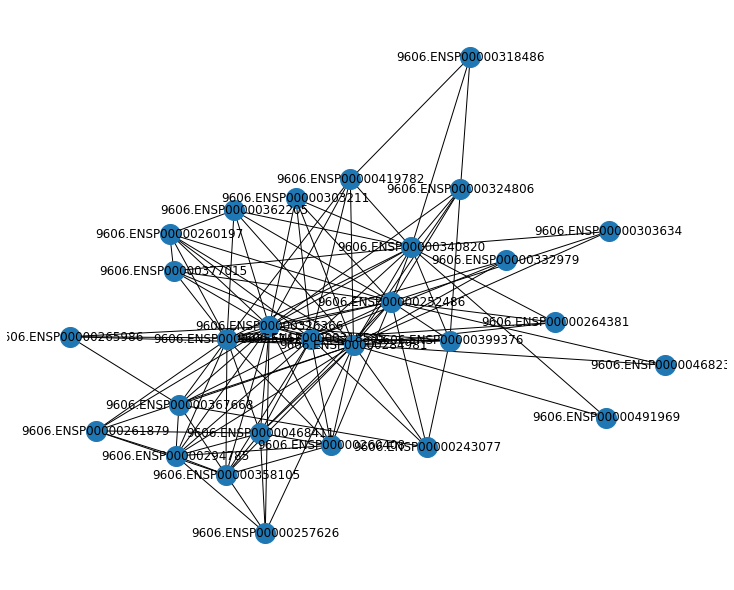

In [84]:
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10,8))
nx.draw(G, pos, with_labels=True, node_size=400)
plt.show()

In [85]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 28
Number of edges: 120


In [86]:
# compute degrees for all nodes
degree = dict(G.degree())

# sort by number of connections, descending
sorted_degree = sorted(degree.items(), key=lambda x: x[1], reverse=True)

# look at top 10
sorted_degree[:10]

[('9606.ENSP00000284981', 26),
 ('9606.ENSP00000326366', 21),
 ('9606.ENSP00000318585', 18),
 ('9606.ENSP00000252486', 17),
 ('9606.ENSP00000355747', 16),
 ('9606.ENSP00000340820', 15),
 ('9606.ENSP00000468411', 10),
 ('9606.ENSP00000358105', 10),
 ('9606.ENSP00000294785', 10),
 ('9606.ENSP00000260408', 8)]

In [87]:
annotations = pd.read_csv("string_protein_annotations.tsv", sep="\t")

# mapping
id_to_name = dict(zip(annotations['identifier'], annotations['#node']))

# hub list
hubs = ['9606.ENSP00000284981', '9606.ENSP00000326366', '9606.ENSP00000318585',
        '9606.ENSP00000252486', '9606.ENSP00000355747', '9606.ENSP00000340820',
        '9606.ENSP00000468411', '9606.ENSP00000358105', '9606.ENSP00000294785',
        '9606.ENSP00000260408']

named_hubs = [(id_to_name.get(x, x), d) for x,d in sorted_degree[:10]]
named_hubs

[('APP', 26),
 ('PSEN1', 21),
 ('BACE1', 18),
 ('APOE', 17),
 ('PSEN2', 16),
 ('MAPT', 15),
 ('PSENEN', 10),
 ('APH1A', 10),
 ('NCSTN', 10),
 ('ADAM10', 8)]

In [103]:
# relabel graph nodes
G_named = nx.relabel_nodes(G, id_to_name)

for u,v,d in list(G_named.edges(data=True))[:5]:
    print(d)

{'combined_score': 0.769}
{'combined_score': 0.937}
{'combined_score': 0.751}
{'combined_score': 0.817}
{'combined_score': 0.831}


In [104]:
degree = dict(G_named.degree())

# scale sizes for plotting
node_sizes = [degree[n]*80 for n in G_named.nodes()]

In [105]:
amyloid = {'APP', 'BACE1', 'PSEN1', 'PSEN2'}
tau = {'MAPT', 'GSK3B', 'CDK5'}

node_colors = []

for node in G_named.nodes():
    if node in amyloid:
        node_colors.append('red')
    elif node in tau:
        node_colors.append('blue')
    else:
        node_colors.append('lightgreen')

In [106]:
pos = nx.spring_layout(G_named, seed=42)

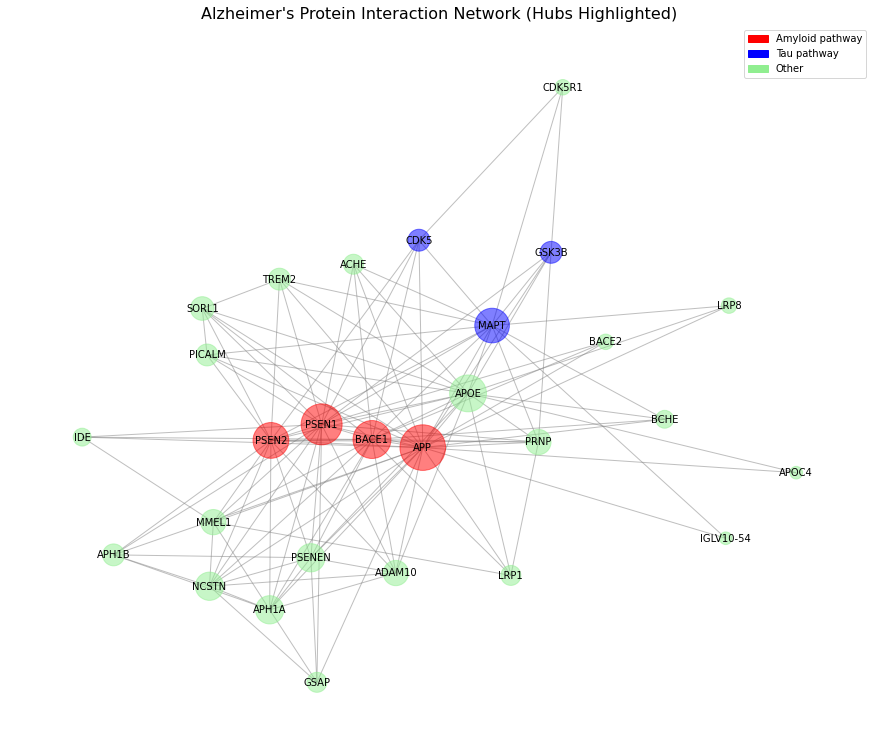

In [136]:
# get top or all hubs
top_nodes = [n for n,_ in sorted(degree.items(), key=lambda x: x[1], reverse=True)[:28]]

labels = {n: n for n in top_nodes}

plt.figure(figsize=(12,10))

nx.draw(
    G_named,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edge_color='gray',
    alpha=0.5
)

nx.draw_networkx_labels(G_named, pos, labels=labels, font_size=10)

plt.title("Alzheimer's Protein Interaction Network (Hubs Highlighted)", fontsize=16)

red_patch = mpatches.Patch(color='red', label='Amyloid pathway')
blue_patch = mpatches.Patch(color='blue', label='Tau pathway')
green_patch = mpatches.Patch(color='lightgreen', label='Other')

plt.legend(handles=[red_patch, blue_patch, green_patch])

plt.show()

The network visualization highlights APP as the central hub (largest node), with distinct clusters corresponding to amyloid processing (red) and tau phosphorylation (blue). Additional proteins identified through STRING expansion form connections between these modules, suggesting integrated signaling pathways in Alzheimer’s disease.

In [108]:
from networkx.algorithms import community

# detect communities
communities = community.greedy_modularity_communities(G_named)

# assign each node to a community
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

In [109]:
# create color list
colors = [community_map[n] for n in G_named.nodes()]

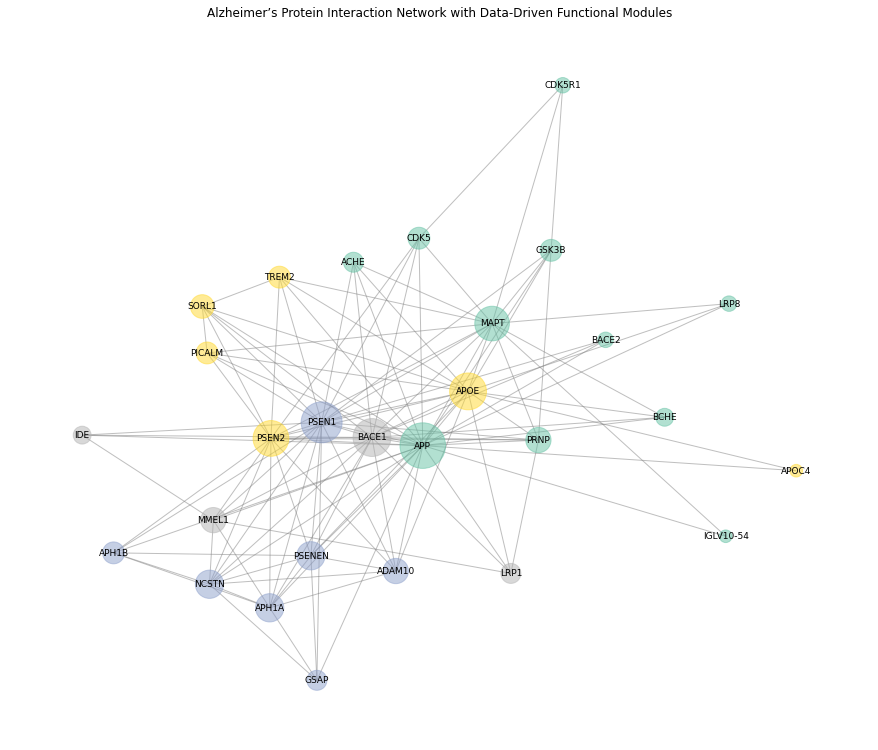

In [135]:
plt.figure(figsize=(12,10))

nx.draw(
    G_named,
    pos,
    node_size=node_sizes,
    node_color=colors,
    cmap=plt.cm.Set2,
    with_labels=False,
    edge_color='gray',
    alpha=0.5
)

nx.draw_networkx_labels(G_named, pos, labels=labels, font_size=9)

plt.title("Alzheimer’s Protein Interaction Network with Data-Driven Functional Modules")

plt.show()

In addition to known pathways, unsupervised community detection revealed functional modules within the network, corresponding to amyloid processing and tau-related signaling.
Community detection grouped proteins based on interaction patterns alone, and these groups correspond to known biological pathways such as amyloid processing and tau signaling.

In [130]:
# I focused on high-confidence interactions to identify the most biologically reliable connections.
strong_edges = [(u,v) for u,v,d in G_named.edges(data=True) if d['combined_score'] > 0.99 ]
strong_edges[:10]

[('APOE', 'LRP1'),
 ('APOE', 'MAPT'),
 ('APOE', 'TREM2'),
 ('APOE', 'SORL1'),
 ('APOE', 'LRP8'),
 ('APOE', 'APP'),
 ('APP', 'SORL1'),
 ('APP', 'IDE'),
 ('APP', 'MAPT'),
 ('APP', 'PRNP')]

In [131]:
nx.shortest_path(G_named, source='APP', target='MAPT')

['APP', 'MAPT']

Shortest path analysis highlights how key proteins from different pathways may be functionally connected through intermediate proteins.